In [2]:
!pip install albumentations --quiet
!pip install segmentation-models-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import os
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from datasets import load_dataset, concatenate_datasets
from tqdm import tqdm

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
dataset = load_dataset("RationAI/PanNuke")

folds = [dataset["fold1"], dataset["fold2"], dataset["fold3"]]

README.md: 0.00B [00:00, ?B/s]

data/fold1-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

data/fold2-00000-of-00001.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

data/fold3-00000-of-00001.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating fold1 split:   0%|          | 0/2656 [00:00<?, ? examples/s]

Generating fold2 split:   0%|          | 0/2523 [00:00<?, ? examples/s]

Generating fold3 split:   0%|          | 0/2722 [00:00<?, ? examples/s]

In [6]:
fold1 = dataset["fold1"]
fold2 = dataset["fold2"]
fold3 = dataset["fold3"]

data = concatenate_datasets([fold1, fold2, fold3])

In [7]:
def get_train_transforms():
    return A.Compose([
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.1, 0.1),rotate=(-30, 30), p=0.5),
        A.ElasticTransform(alpha=1, sigma=50, p=0.3),
        A.RandomBrightnessContrast(p=0.5),

        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        

        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        
        ToTensorV2()
    ])

train_tfms = get_train_transforms()
val_tfms   = get_val_transforms()
def prepare_binary_masks(masks):
    # masks shape: (N, 256, 256, 6)
    # sum all cell type channels (0-4), ignore background channel (5)
    binary_mask = masks[..., :5].sum(axis=-1)
    binary_mask = (binary_mask > 0).astype(np.float32)
    return binary_mask  # shape: (N, 256, 256)

image: (256, 256, 3)
instances: (8, 256, 256)
wrong mask: (8, 256)
correct mask: (256, 256)


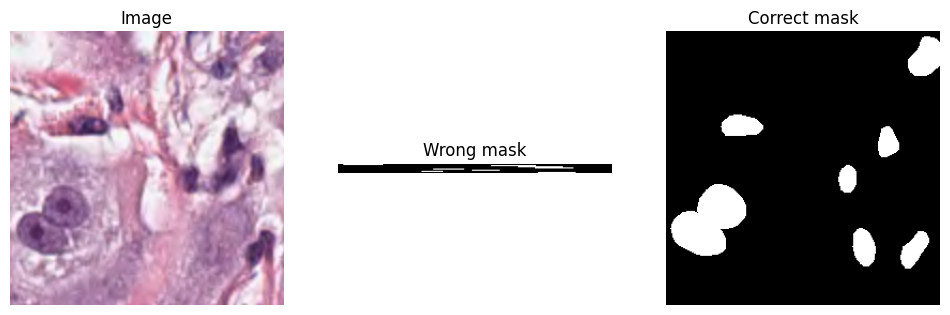

In [10]:
import numpy as np
import matplotlib.pyplot as plt

sample = dataset["fold1"][0]   # or use train_data[0] if train_data exists

image = np.asarray(sample["image"]).astype(np.uint8)
instances = np.asarray(sample["instances"])  # N, H, W

print("image:", image.shape)
print("instances:", instances.shape)

wrong_mask = (instances.sum(axis=-1) > 0).astype(np.float32)
correct_mask = (instances.sum(axis=0) > 0).astype(np.float32)

print("wrong mask:", wrong_mask.shape)
print("correct mask:", correct_mask.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(wrong_mask, cmap="gray")
plt.title("Wrong mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(correct_mask, cmap="gray")
plt.title("Correct mask")
plt.axis("off")

plt.show()


In [12]:
class PanNukeDataset(Dataset):
    def __init__(self, hf_dataset, transforms=None):
        self.data = hf_dataset
        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        image = np.asarray(sample["image"]).astype(np.uint8)
        instances = np.asarray(sample["instances"])  # N, H, W

        if instances.size == 0:
            mask = np.zeros(image.shape[:2], dtype=np.float32)
        else:
            mask = (instances.sum(axis=0) > 0).astype(np.float32)

        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float()

        return image, mask


In [15]:
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    return np.clip(img, 0, 1)


In [9]:
img, mask = train_dataset[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0).cpu().numpy())
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze().cpu().numpy(), cmap="gray")
plt.title("GT Mask")
plt.axis("off")

plt.show()


NameError: name 'train_dataset' is not defined

In [16]:
print(train_tfms)
print(val_tfms)

Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
  RandomRotate90(p=0.5),
  Affine(p=0.5, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-30.0, 30.0), rotate_method='largest_box', scale={'x': (0.9, 1.1), 'y': (0.9, 1.1)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent={'x': (0.1, 0.1), 'y': (0.1, 0.1)}, translate_px=None),
  ElasticTransform(p=0.3, alpha=1.0, approximate=False, border_mode=0, fill=0.0, fill_mask=0.0, interpolation=1, keypoint_remapping_method='mask', mask_interpolation=0, noise_distribution='gaussian', same_dxdy=False, sigma=50.0),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normaliza

In [20]:
dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
focal = smp.losses.FocalLoss(mode="binary")

def combined_loss(pred, target):
    return dice(pred, target) + 0.5 * focal(pred, target)


In [ ]:
def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return 1 - dice


bce_loss = nn.BCEWithLogitsLoss()



In [ ]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))

    dice = (2 * intersection + 1e-8) / (union + 1e-8)
    return dice.mean().item()

In [17]:
def train_model(model, train_loader, val_loader, fold, epochs=10):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=2, factor=0.5
    )

    best_dice = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        loop = tqdm(train_loader, desc=f"Fold {fold} Epoch {epoch+1}")

        for images, masks in loop:
            images = images.to(device)
            masks  = masks.to(device).float()

            optimizer.zero_grad()

            outputs = model(images)
            loss = combined_loss(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)

        # ✅ validation
        model.eval()
        val_dice = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.to(device).float()

                outputs = model(images)
                val_dice += dice_score(outputs, masks)

        val_dice /= len(val_loader)

        scheduler.step(val_dice)

        print(f"[Fold {fold}] Epoch {epoch+1}: Loss={train_loss:.4f}, Dice={val_dice:.4f}")

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.state_dict(), f"best_fold_{fold}.pth")

    return best_dice

In [ ]:
count_empty = 0

for i in range(200):  # sample some data
    _, m = train_dataset[i]
    if m.sum() == 0:
        count_empty += 1

print("Empty masks:", count_empty)

In [ ]:
fold_scores = []

for i in range(3):

    print(f"\n===== FOLD {i+1} STARTED =====")

    val_data = folds[i]
    train_data = concatenate_datasets([folds[j] for j in range(3) if j != i])

    train_dataset = PanNukeDataset(train_data, transforms=train_tfms)
    val_dataset   = PanNukeDataset(val_data, transforms=val_tfms)

    print("Train dataset:", len(train_dataset))

    train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=10, shuffle=False, num_workers=2)

    print("Train batches:", len(train_loader))

    model = smp.Unet(
        encoder_name="efficientnet-b4",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )

    model = model.to(device)

    val_dice = train_model(model, train_loader, val_loader, fold=i+1)

    fold_scores.append(val_dice)

    torch.cuda.empty_cache()

print("\n===== FINAL RESULTS =====")
for i, score in enumerate(fold_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"Mean Dice: {sum(fold_scores)/len(fold_scores):.4f}")


===== FOLD 1 STARTED =====
Train dataset: 5245
Train batches: 525


Fold 1 Epoch 1:  24%|██▍       | 125/525 [15:18<48:51,  7.33s/it, loss=0.49]  

In [ ]:
model.load_state_dict(torch.load("your_model.pth", map_location=device))
model.eval()

In [ ]:
print("PanNukeSMPDataset" in globals())

In [ ]:
data_iter = iter(val_loader)
images, masks = next(data_iter)

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)

In [ ]:
preds = torch.sigmoid(outputs)
preds = (preds > 0.5).float()

In [ ]:
import matplotlib.pyplot as plt

for i in range(3):  # change number as needed
    img = images[i].cpu().permute(1, 2, 0).numpy()
    gt = masks[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    plt.figure(figsize=(12, 3))
    

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred, cmap='gray')
    plt.axis('off')

    plt.show()

In [ ]:
for i in range(3):
    gt = masks[i].cpu().squeeze().numpy()
    pred = preds[i].cpu().squeeze().numpy()

    error = (gt != pred)

    plt.imshow(error, cmap='hot')
    plt.title("Error Map")
    plt.axis('off')
    plt.show()

In [ ]:
for t in [0.2, 0.3, 0.4, 0.5]:
    preds = (torch.sigmoid(outputs) > t).float()
    print("Threshold:", t, "Dice:", dice_score(preds, masks))

In [ ]:
img = images[0].cpu().permute(1,2,0).numpy()
gt = masks[0].cpu().squeeze().numpy()
pred = torch.sigmoid(outputs[0]).cpu().squeeze().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("GT")
plt.imshow(gt, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Prediction (raw prob)")
plt.imshow(pred, cmap='gray')
plt.axis('off')

plt.show()